In [1]:
import os
import sys
current_dir = os.getcwd()
root_path = os.path.abspath(os.path.join(current_dir, '..', '..'))
if root_path not in sys.path:
    sys.path.append(root_path)
import torch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch.nn as nn
import numpy as np
import pickle
import pandas as pd
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import math
import scipy.special
import random as rd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import torch.optim.lr_scheduler as lr_scheduler
from python_scripts.sgp_utils import *
from python_scripts.plotting import *
from python_scripts.preprocessing import *
from scipy.special import gammaln
import warnings
warnings.filterwarnings("ignore")
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


In [2]:
sgp_df_SR = pickle.load(open('sgp_set_cnn','rb')) 
print(sgp_df_SR.shape)
print('1s prop = ', sgp_df_SR.y_true.sum()/sgp_df_SR.shape[0])
sgp_df_SR.head() 

(6788, 3)
1s prop =  0.3320565704183854


,y_true,y_pred,kappa
0,0.0,0.0,0.985617
1,1.0,1.0,0.899486
2,1.0,1.0,0.952112
3,0.0,0.0,0.994921
4,0.0,0.0,0.978682


In [3]:
sgp_df_MCD = pickle.load(open('sgp_set_cnn_MCD','rb')) 
print(sgp_df_MCD.shape)
sgp_df_MCD.head() 

(6788, 3)


,y_true,y_pred,kappa
0,0.0,0.0,-0.000600
1,1.0,1.0,-0.003494
2,1.0,1.0,-0.001536
3,0.0,0.0,-0.000046
4,0.0,0.0,-0.001196


In [4]:
train_set_SR = sgp_df_SR.iloc[:3*int(len(sgp_df_SR)/4)]
train_set_SR = train_set_SR.sort_values('kappa', ascending=True).reset_index(drop=True).copy()
test_set_SR = sgp_df_SR.iloc[3*int(len(sgp_df_SR)/4):]

train_set_MCD = sgp_df_MCD.iloc[:3*int(len(sgp_df_MCD)/4)]
train_set_MCD = train_set_MCD.sort_values('kappa', ascending=True).reset_index(drop=True).copy()
test_set_MCD = sgp_df_MCD.iloc[3*int(len(sgp_df_MCD)/4):]

In [5]:
delta = 0.005

In [6]:
color_map = {'standard': "#d51414",
             'FP': "#e5be12",
             'FN': "#27e21d",
             'FPR': "#403535",
             'FNR': "#1d3ae2",
             'SE': "#d51de2",
             'SP': "#16CEE2",
             'PPV': "#676767"}

### Joint evolution of metrics with respect to $\theta$ and coverage

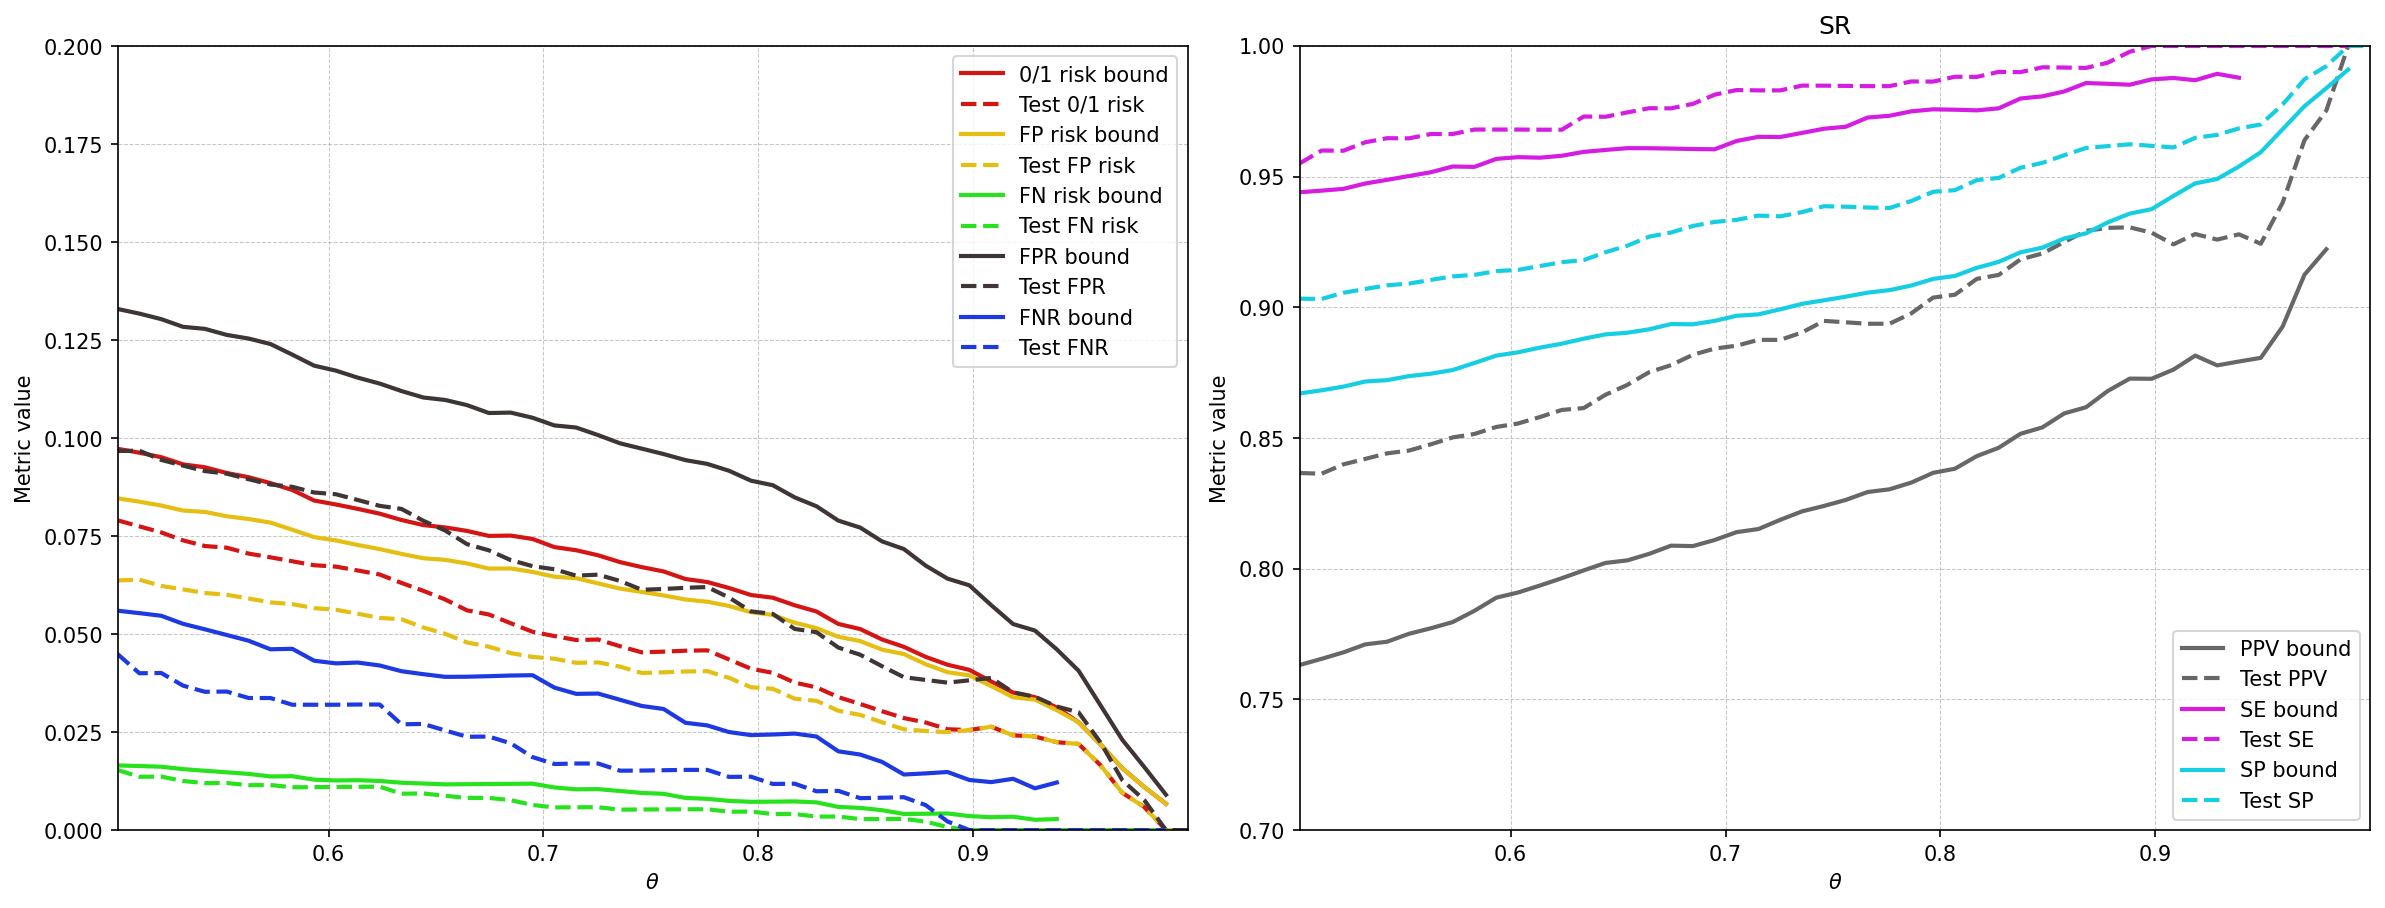

In [7]:
plot_all_metrics(train_set_SR, test_set_SR,
                 delta, color_map, title='SR',
                 xlim1=[0.5,1], xlim2=[0.5,1],
                 ylim1=[0,0.2], ylim2=[0.7,1])

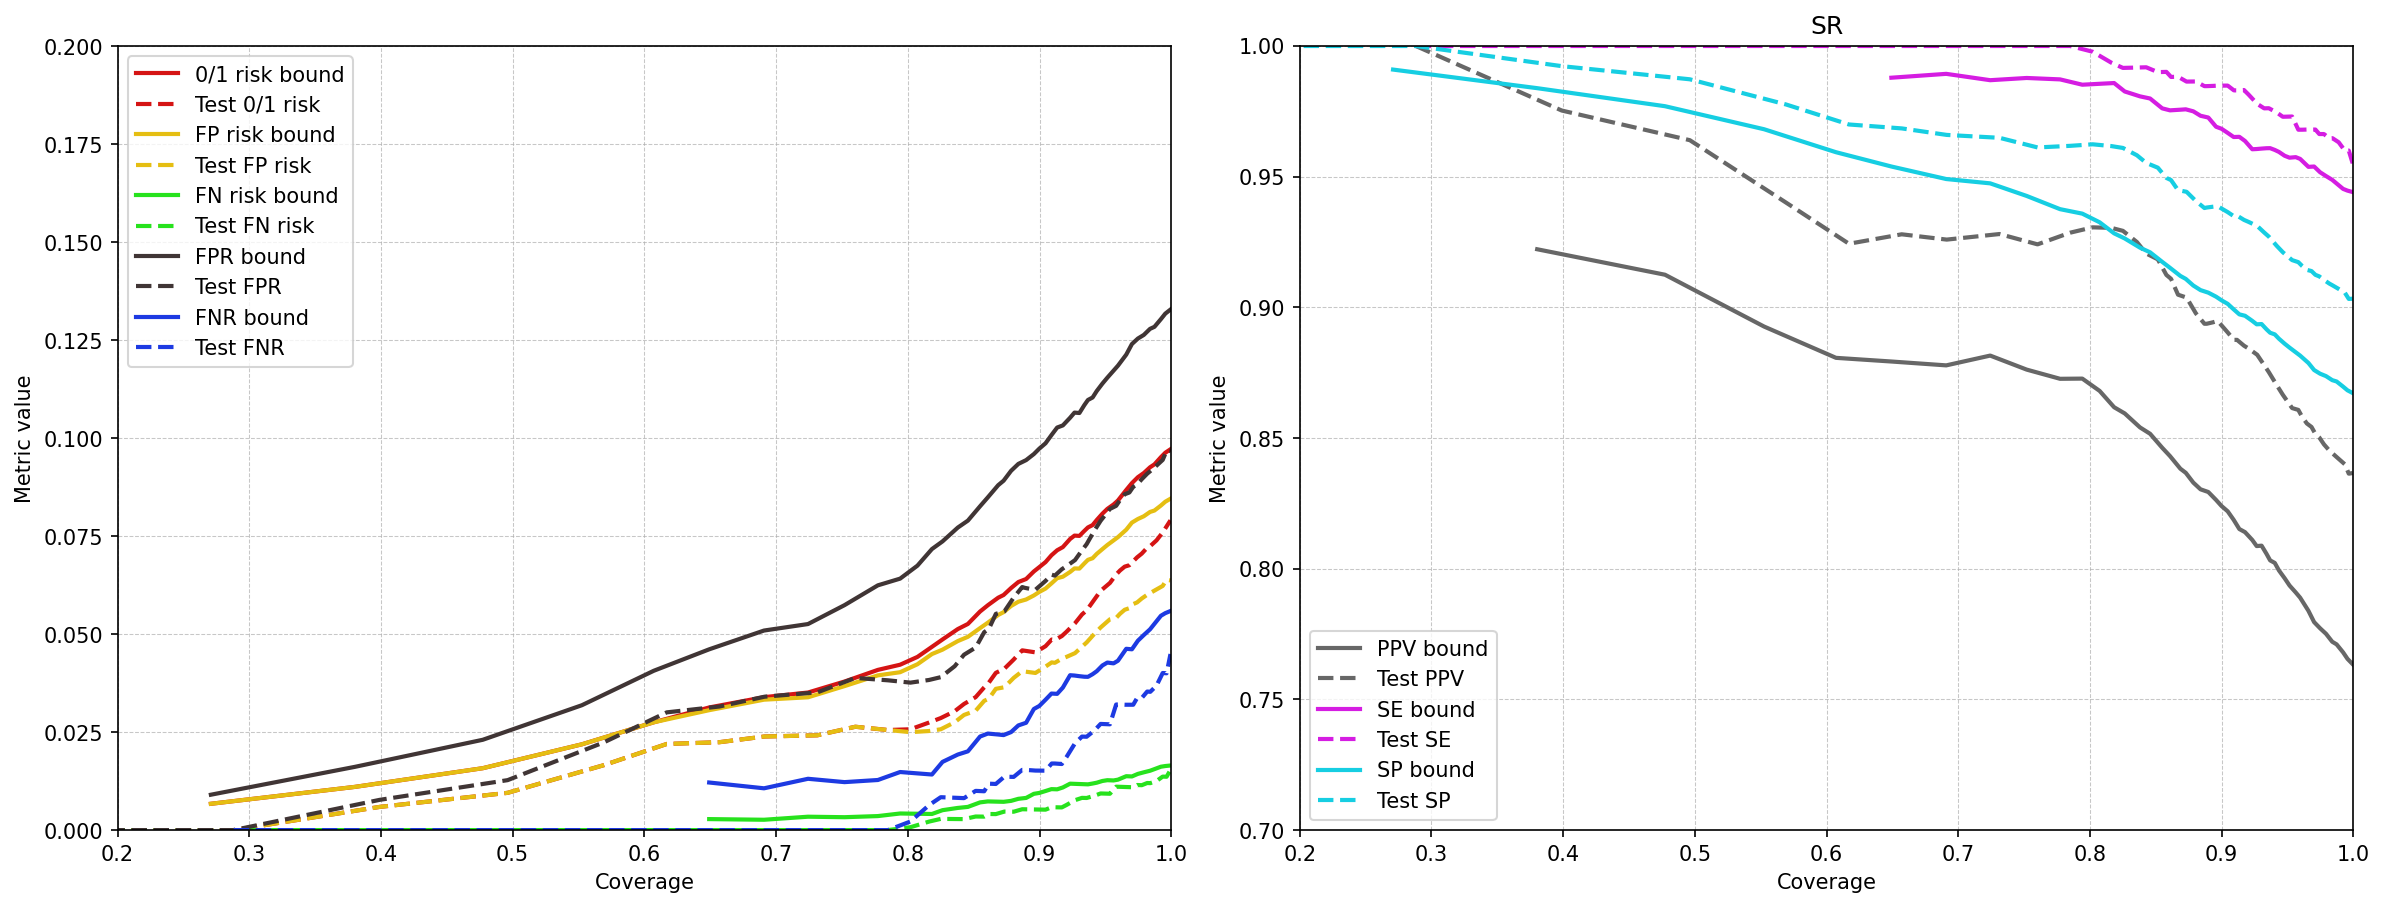

In [8]:
plot_all_metrics(train_set_SR, test_set_SR,
                 delta, color_map, title='SR',
                 xlim1=[0.2,1], xlim2=[0.2,1],
                 ylim1=[0,0.2], ylim2=[0.7,1],
                 by_coverage=True)

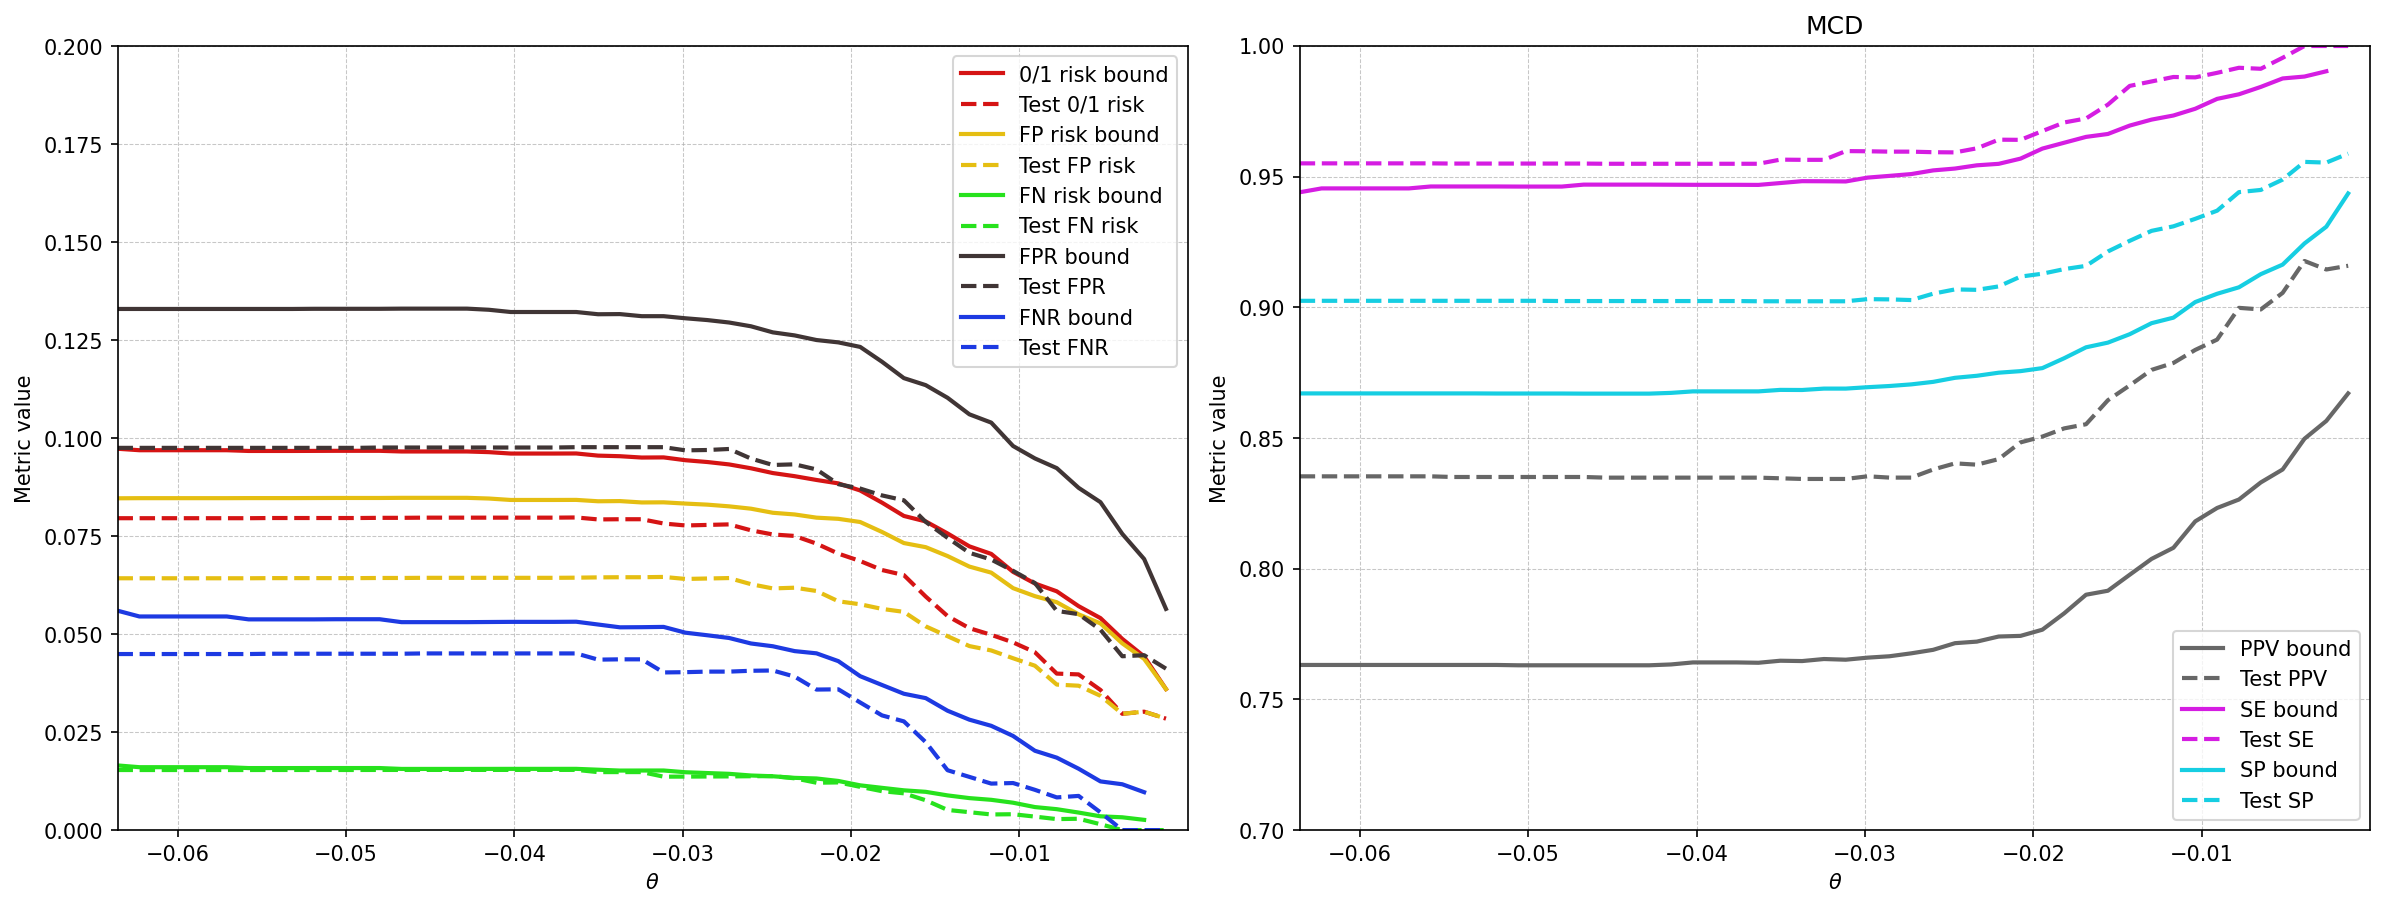

In [9]:
plot_all_metrics(train_set_MCD, test_set_MCD,
                 delta, color_map, title='MCD',
                 xlim1=[-0.07,0], xlim2=[-0.07,0],
                 ylim1=[0,0.2], ylim2=[0.7,1])

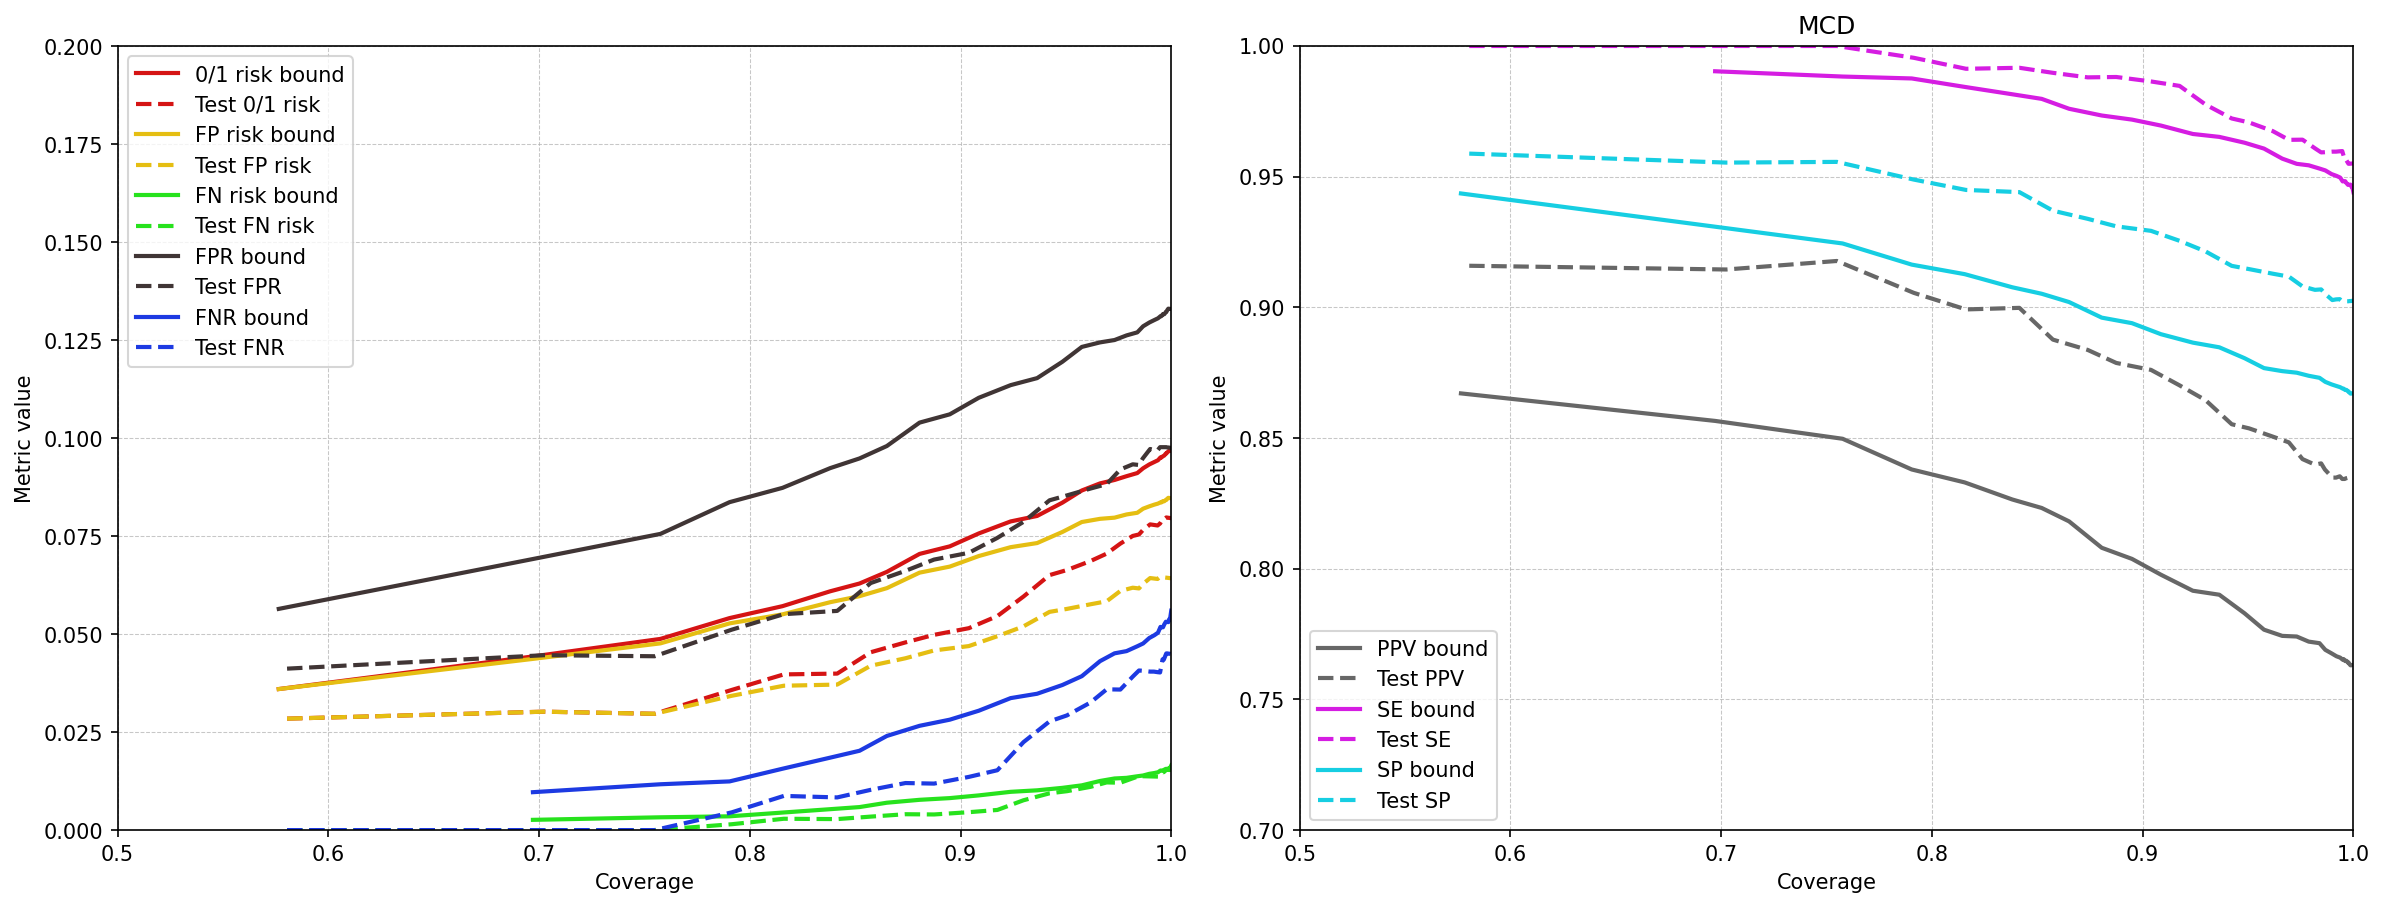

In [10]:
plot_all_metrics(train_set_MCD, test_set_MCD,
                 delta, color_map, title='MCD',
                 xlim1=[0.5,1], xlim2=[0.5,1],
                 ylim1=[0,0.2], ylim2=[0.7,1],
                 by_coverage=True)

### Find best $\theta$ in the intersection of metrics $\theta$ regions, if non empty

In [11]:
metrics_and_targets = {'FNR' : 0.2,
                       'FPR' : 0.1}

In [12]:
joint_output = joint_control(metrics_and_targets, train_set_SR, delta, plot=False)
joint_output

{'theta_intervals': [(np.float64(0.7282402407039296),
   np.float64(0.9446346958478292))],
 'best_theta': np.float64(0.7282402407039296)}

### All reachable bounds for a couple of 2 metrics

In [13]:
metrics = ['standard', 'FP', 'FN', 'FPR',
           'FNR','PPV', 'SE','SP']

all_bounds_SR = reachable_bounds(metrics, train_set_SR, delta, steps=100)
all_bounds_MCD = reachable_bounds(metrics, train_set_MCD, delta, steps=100)

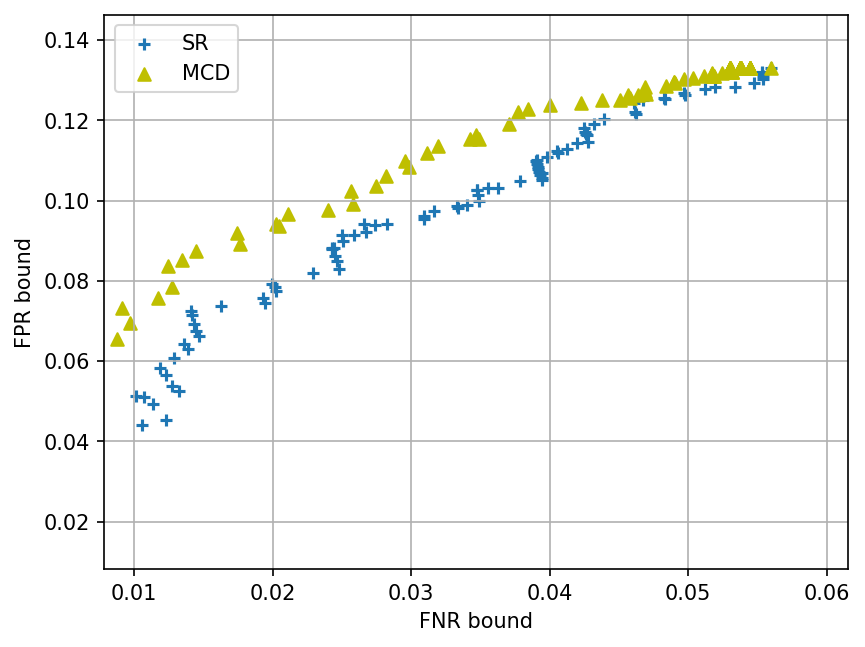

In [14]:
metric1 = 'FNR'
metric2 = 'FPR'

two_metrics_bounds(metric1, metric2, all_bounds_SR, all_bounds_MCD, num_labels=0)